In [1]:
import happi
from scipy.signal import hilbert
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
print(animation.writers.list())
import pint
import os
from numpy import array, pi
import matplotlib as mpl
from matplotlib.colors import LogNorm
import scipy.constants as const
from IPython.display import Video

mpl.rcParams.update({
    'font.family'      :'serif',
    'font.serif'       :'Times',
    'font.size'        :16,
    'xtick.major.size' :10,
    'ytick.major.size' :10,
    'xtick.minor.size' :5,
    'ytick.minor.size' :5,
})

['pillow', 'html']


In [2]:
ureg = pint.UnitRegistry()
S = happi.Open("/rds/general/user/aa3422/home/week8/prepulse_no_sqrt", verbose=False)
ffmpeg_dir = "/rds/general/user/aa3422/home/miniforge3/envs/test1/bin/"
os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ["PATH"]

dt = 0.004252 # what is dt? check

Simulation time:  12.0 ps
dx :  0.006135923151542565
Cluster profile:  91.0


In [3]:
lambda0 = 0.8e-6  # put in metres
kL = 2*np.pi/lambda0
omega0 = 2*np.pi*const.c/lambda0
ncrit = const.epsilon_0*const.m_e*omega0**2/const.e**2   # m^-3

ncrit_cm3 = ncrit/1e6                 # cm^-3
c_over_omega0 = const.c/omega0
Lx = 1e-6/c_over_omega0
Ly = Lx

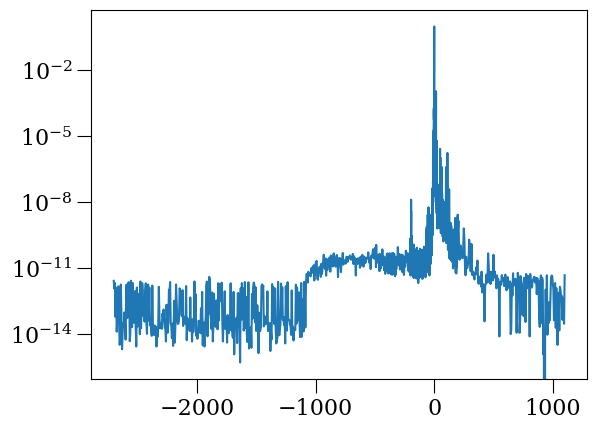

In [4]:
gemini = np.loadtxt("gemini_prepulse_clean.csv", delimiter=",", skiprows=1)

I_norm = gemini[:,0]
t_ps = gemini[:,1]


mask = np.isfinite(I_norm) & np.isfinite(t_ps)

I_norm = I_norm[mask]
t_ps = t_ps[mask]


I_norm /= np.max(I_norm)

plt.semilogy(t_ps, I_norm)
plt.show()

# a0 = 1.2

# # start simulation at -10 ps

# t_start_ps = -10.0

# t_sim_ps = t_ps - t_start_ps

# laser_time = t_sim_ps*1e-12*omega0

# simulation_time_ps = 12.0

# def gemini_envelope(t):

#     intensity = np.interp(
#         t,
#         laser_time,
#         I_norm,
#         left=0.0,
#         right=0.0
#     )

    

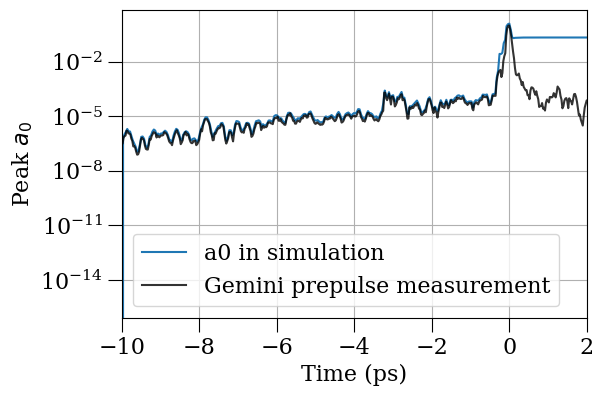

In [5]:
Ey = S.Field(0, "Ey")

times = Ey.getTimes()

a0 = []

for it in Ey.getTimesteps():

    field = Ey.getData(timestep=it)

    field = np.array(field)

    a0.append(np.max(np.abs(field)))


time_sim = times/omega0*1e12 - 10
a0 = np.array(a0)
plt.figure(figsize=(6,4))

plt.semilogy(time_sim, a0, label='a0 in simulation')
plt.semilogy(t_ps, I_norm, color='black', label='Gemini prepulse measurement', alpha=0.8)

plt.xlabel("Time (ps)")
plt.xlim(-10, 2)
plt.ylabel("Peak $a_0$")
plt.grid()
plt.legend()
plt.savefig('comparison_a0.pdf', dpi=400, bbox_inches='tight')
plt.show()

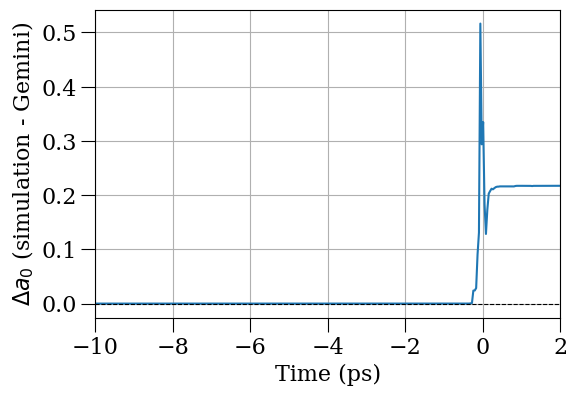

In [6]:
Ey = S.Field(0, "Ey")

times = Ey.getTimes()

a0 = []

for it in Ey.getTimesteps():
    field = np.array(Ey.getData(timestep=it))
    a0.append(np.max(np.abs(field)))

time_sim = times / omega0 * 1e12 - 10
a0 = np.array(a0)

# Interpolate Gemini prepulse onto simulation time points
I_norm_interp = np.interp(
    time_sim,
    t_ps,
    I_norm,
    left=0.0,
    right=0.0
)

# Difference: simulation - Gemini
difference = a0 - I_norm_interp

plt.figure(figsize=(6, 4))
plt.plot(time_sim, difference)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Time (ps)")
plt.ylabel(r"$\Delta a_0$ (simulation - Gemini)")
plt.xlim(-10, 2)
plt.grid()
plt.show()